In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, f1_score, precision_score, recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


import sys
from pathlib import Path

# Get project root
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

%load_ext autoreload
%autoreload 2

import utils.evaluation as evaluate
import utils.visualization_utils as visualize

In [2]:
fraud_df = pd.read_csv("../data/full_data.csv")

print("Full Data")
display(fraud_df.head())

Full Data


,TERMINAL_ID,x_terminal_id,y_terminal_id,CUSTOMER_ID,x_customer_id,y_customer_id,mean_amount,std_amount,mean_nb_tx_per_day,nb_terminals,...,day,day_name,day_of_week,is_weekend,tx_hour,customer_terminal_distance,distance_bucket,amount_zscore,zscore_bucket,amount_above_mean
0,0,41.7022,72.032449,399,45.265353,71.371776,91.963727,45.981863,0.586335,76,...,11,Saturday,5,1,8,3.623885,"(3.507, 3.848]",0.868305,"(0.553, 0.872]",1
1,0,41.7022,72.032449,504,46.185344,72.624328,50.112812,25.056406,3.616203,71,...,18,Friday,4,0,7,4.522046,"(4.459, 4.737]",1.350840,"(1.319, 79.922]",1
2,0,41.7022,72.032449,504,46.185344,72.624328,50.112812,25.056406,3.616203,71,...,16,Saturday,5,1,7,4.522046,"(4.459, 4.737]",-0.844607,"(-1.182, -0.784]",0
3,0,41.7022,72.032449,504,46.185344,72.624328,50.112812,25.056406,3.616203,71,...,21,Thursday,3,0,15,4.522046,"(4.459, 4.737]",0.867929,"(0.553, 0.872]",1
4,0,41.7022,72.032449,504,46.185344,72.624328,50.112812,25.056406,3.616203,71,...,16,Monday,0,0,20,4.522046,"(4.459, 4.737]",0.212608,"(0.0303, 0.283]",1


In [3]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1754155 entries, 0 to 1754154
Data columns (total 27 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   TERMINAL_ID                 int64  
 1   x_terminal_id               float64
 2   y_terminal_id               float64
 3   CUSTOMER_ID                 int64  
 4   x_customer_id               float64
 5   y_customer_id               float64
 6   mean_amount                 float64
 7   std_amount                  float64
 8   mean_nb_tx_per_day          float64
 9   nb_terminals                int64  
 10  TRANSACTION_ID              int64  
 11  TX_DATETIME                 str    
 12  TX_AMOUNT                   float64
 13  TX_TIME_SECONDS             int64  
 14  TX_TIME_DAYS                int64  
 15  TX_FRAUD                    int64  
 16  TX_FRAUD_SCENARIO           int64  
 17  day                         int64  
 18  day_name                    str    
 19  day_of_week                 int6

#### Preparing data for Training

In [4]:
fraud_df["TX_DATETIME"] = pd.to_datetime(fraud_df["TX_DATETIME"])

In [5]:
COLS_TO_DROP = ["TERMINAL_ID", 
                "TRANSACTION_ID", 
                "std_amount", 
                "TX_TIME_SECONDS",
                "TX_FRAUD_SCENARIO",
                "x_terminal_id",
                "y_terminal_id",
                "x_customer_id",
                "y_customer_id"
                ]

TARGET = "TX_FRAUD"

#### Split Data

In [6]:
# Drop columns first
X = fraud_df.drop(columns=COLS_TO_DROP)
y = fraud_df[TARGET]

# Combine X and y to preserve alignment
data = X.copy()
data[TARGET] = y

# Sort by time
data_sorted = data.sort_values("TX_DATETIME")

# Split index
split_idx = int(len(data_sorted) * 0.8)

# Split
train_data = data_sorted.iloc[:split_idx]
test_data  = data_sorted.iloc[split_idx:]

# Separate again
X_train = train_data.drop(columns=[TARGET, "TX_DATETIME"])
y_train = train_data[TARGET]

X_test = test_data.drop(columns=[TARGET])
y_test = test_data[TARGET]

In [7]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 1403324 entries, 553763 to 264210
Data columns (total 16 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   CUSTOMER_ID                 1403324 non-null  int64  
 1   mean_amount                 1403324 non-null  float64
 2   mean_nb_tx_per_day          1403324 non-null  float64
 3   nb_terminals                1403324 non-null  int64  
 4   TX_AMOUNT                   1403324 non-null  float64
 5   TX_TIME_DAYS                1403324 non-null  int64  
 6   day                         1403324 non-null  int64  
 7   day_name                    1403324 non-null  str    
 8   day_of_week                 1403324 non-null  int64  
 9   is_weekend                  1403324 non-null  int64  
 10  tx_hour                     1403324 non-null  int64  
 11  customer_terminal_distance  1403324 non-null  float64
 12  distance_bucket             1403324 non-null  str    
 13  amount_zs

In [8]:
# define preprocess pipeline
cat_cols = X_train.select_dtypes(include=["object"]).columns
num_cols = X_train.select_dtypes(exclude=["object"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_cols)
    ]
)

C:\Users\LAP X\AppData\Local\Temp\ipykernel_24696\3528577336.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object"]).columns


#### Logistic Regression Model

In [9]:
# Baseline Model Pipeline
lr_baseline = Pipeline([
    ("preprocess", preprocess),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",   # handles class imbalance automatically
        max_iter=1000,
        random_state=42,
        C=1.0
    ))
])

lr_baseline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['CUSTOMER_ID','mean_amount','mean_nb_tx_per_day',...,'amount_zscore', 'zscore_bucket','amount_above_mean']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spec


==================== Logistic Regression at (Threshold = 0.5) ====================
              precision    recall  f1-score   support

       Legit       0.99      0.72      0.84    347681
       Fraud       0.02      0.52      0.03      3150

    accuracy                           0.72    350831
   macro avg       0.51      0.62      0.43    350831
weighted avg       0.99      0.72      0.83    350831

ROC-AUC:  0.6660
PR-AUC:   0.3275


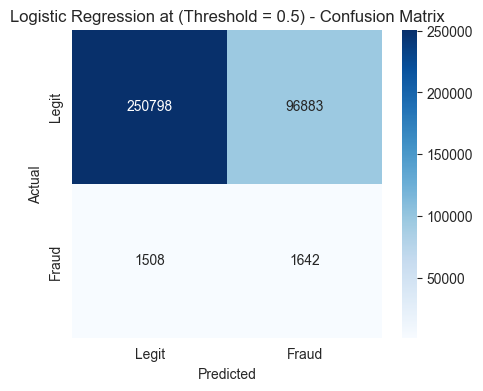

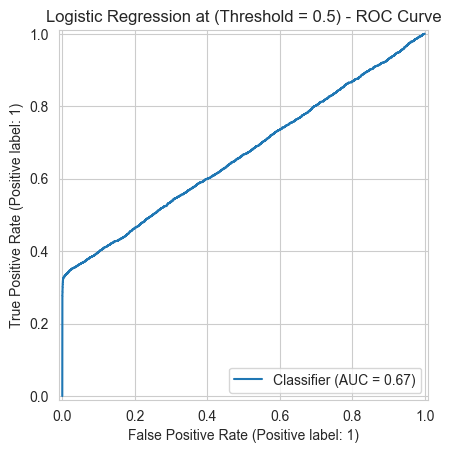

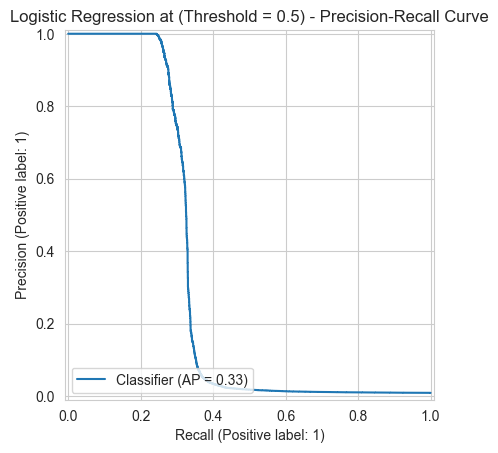

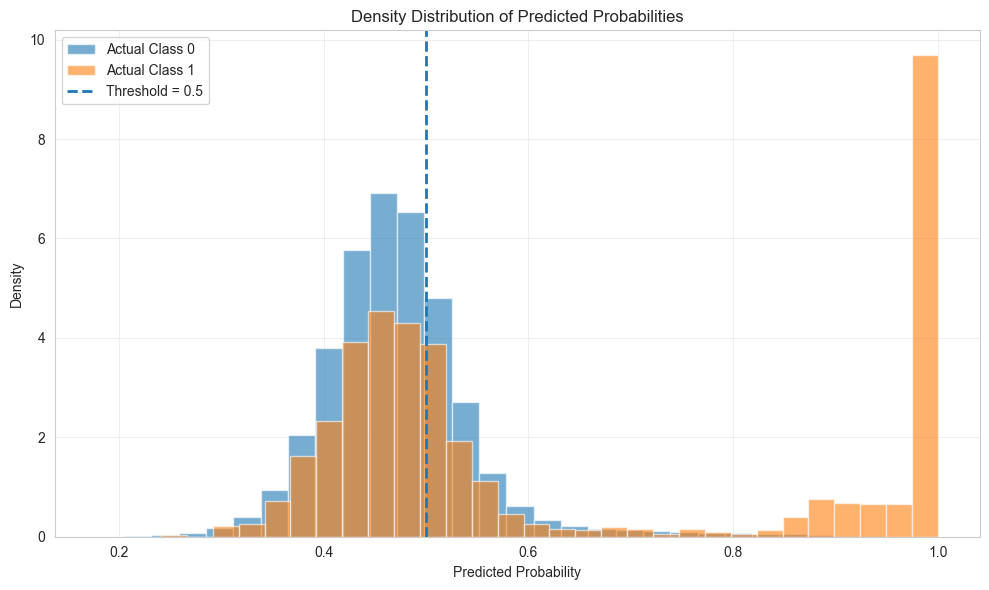

In [10]:
# predictions when threshold = 0.5
y_prob = lr_baseline.predict_proba(X_test)[:, 1]
y_pred = lr_baseline.predict(X_test)

lr_half_threshold = evaluate.evaluate_w_visualization(y_test=y_test, 
                                                    y_pred=y_pred, 
                                                    y_prob=y_prob, 
                                                    model_name="Logistic Regression at (Threshold = 0.5)")

visualize.plot_probability_distribution(y_test, y_prob, threshold=0.5)

In [11]:
baseline_lr_best_threshold, baseline_lr_results = evaluate.find_best_threshold(
    y_test,
    y_prob,
    step=0.01,
    metric="f1"
)

print("Baseline best threshold: ", baseline_lr_best_threshold)


Best threshold (by f1): 0.89
Precision: 0.720
Recall:    0.304
F1:        0.428
Baseline best threshold:  0.89



==================== Logistic Regression at (Threshold = 0.89) ====================
              precision    recall  f1-score   support

       Legit       0.99      1.00      1.00    347681
       Fraud       0.72      0.30      0.43      3150

    accuracy                           0.99    350831
   macro avg       0.86      0.65      0.71    350831
weighted avg       0.99      0.99      0.99    350831

ROC-AUC:  0.6660
PR-AUC:   0.3275


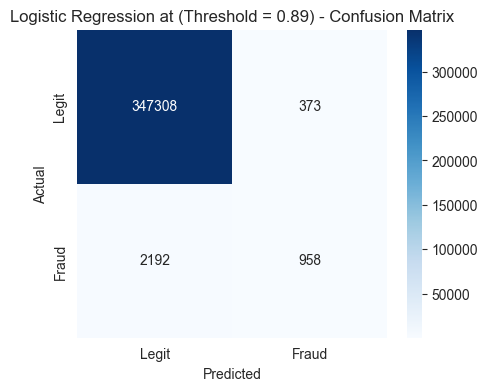

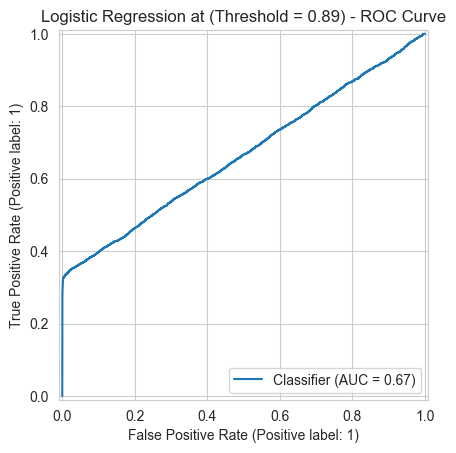

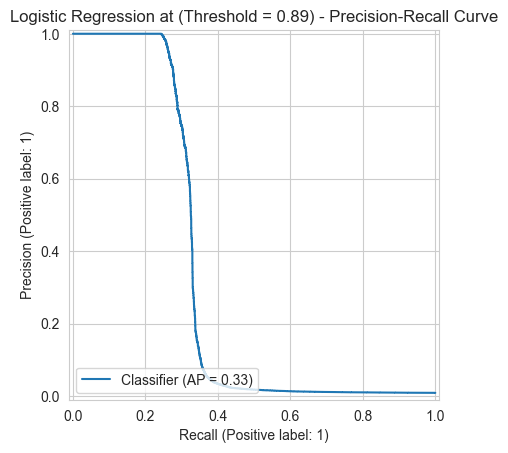

In [12]:
y_prob = lr_baseline.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= baseline_lr_best_threshold).astype(int)

lr_best_eval_dict = evaluate.evaluate_w_visualization(y_test=y_test, 
                                                    y_pred=y_pred, 
                                                    y_prob=y_prob, 
                                                    model_name=f"Logistic Regression at (Threshold = {baseline_lr_best_threshold})")

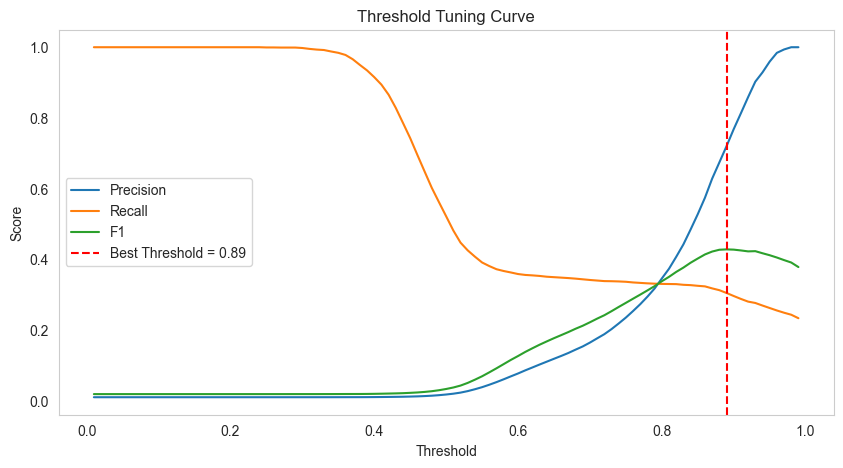

In [13]:
plt.figure(figsize=(10,5))

plt.plot(
    baseline_lr_results["threshold"],
    baseline_lr_results["precision"],
    label="Precision"
)

plt.plot(
    baseline_lr_results["threshold"],
    baseline_lr_results["recall"],
    label="Recall"
)

plt.plot(
    baseline_lr_results["threshold"],
    baseline_lr_results["f1"],
    label="F1"
)

# correct vertical line (single value is fine here)
plt.axvline(
    baseline_lr_best_threshold,
    color="red",
    linestyle="--",
    label=f"Best Threshold = {baseline_lr_best_threshold:.2f}"
)

plt.title("Threshold Tuning Curve")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

## Ensemble Method

In [14]:
# KNN
knn_pipe = Pipeline([
    ("preprocess", preprocess),
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(
        n_neighbors=5,
        metric="euclidean",
        weights="distance",      # closer neighbors vote more
        n_jobs=-1
    ))
])

# LDA
lda_pipe = Pipeline([
    ("preprocess", preprocess),
    ("scaler", StandardScaler()),
    ("clf", LinearDiscriminantAnalysis())
])

# LR
lr_pipe = Pipeline([
    ("preprocess", preprocess),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",   # handles class imbalance automatically
        max_iter=1000,
        random_state=42,
        C=1.0
    ))
])

In [15]:
# Train the 3 models independently
print("Training KNN..."); knn_pipe.fit(X_train, y_train)
print("Training LDA..."); lda_pipe.fit(X_train, y_train)
print("Training LR... "); lr_pipe.fit(X_train, y_train)

Training KNN...
Training LDA...
Training LR... 


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['CUSTOMER_ID','mean_amount','mean_nb_tx_per_day',...,'amount_zscore', 'zscore_bucket','amount_above_mean']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spec

In [ ]:
pKNN = knn_pipe.predict(X_test)                    # binary: 0 or 1
pLDA = lda_pipe.predict(X_test)                    # binary: 0 or 1
pLR  = lr_pipe.predict_proba(X_test)[:, 1]         # probability: 0.0–1.0
# mvLR = lr_pipe.predict_proba(X_train)[:, 1].mean() # mean LR prob on TRAIN set

In [ ]:
mvLR, ensemble_lr_results = evaluate.find_best_threshold(
    y_test,
    pLR,
    step=0.01,
    metric="f1"
)

# mvLR = lr_pipe.predict_proba(X_train)[:, 1].mean()

print("OR Ensemble Model (LR) threshold: ", mvLR)


Best threshold (by f1): 0.89
Precision: 0.720
Recall:    0.304
F1:        0.428
OR Ensemble Model (LR) threshold:  0.89



==================== KNN ====================
              precision    recall  f1-score   support

       Legit       0.99      1.00      1.00    347681
       Fraud       0.99      0.22      0.36      3150

    accuracy                           0.99    350831
   macro avg       0.99      0.61      0.68    350831
weighted avg       0.99      0.99      0.99    350831

ROC-AUC:  0.6348
PR-AUC:   0.2596


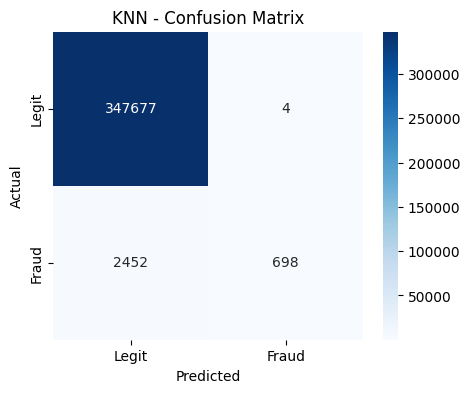

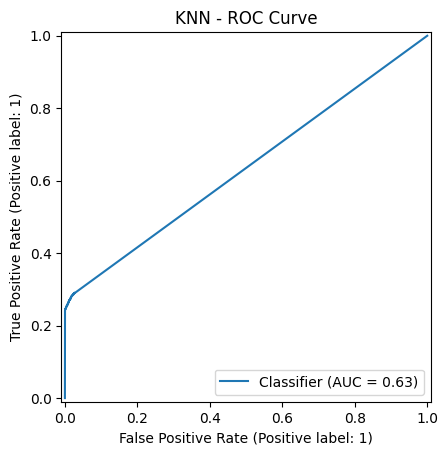

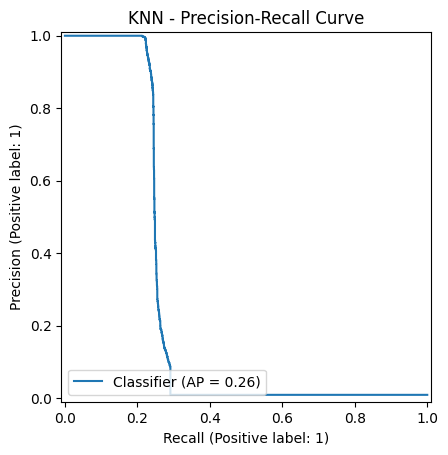

In [ ]:
# evaluate KNN
knn_eval_dict = evaluate.evaluate_w_visualization(y_test=y_test, 
                                                    y_pred=pKNN, 
                                                    y_prob=knn_pipe.predict_proba(X_test)[:,1], 
                                                    model_name=f"KNN")


==================== LDA ====================
              precision    recall  f1-score   support

       Legit       0.99      1.00      1.00    347681
       Fraud       0.76      0.28      0.41      3150

    accuracy                           0.99    350831
   macro avg       0.88      0.64      0.71    350831
weighted avg       0.99      0.99      0.99    350831

ROC-AUC:  0.6669
PR-AUC:   0.3225


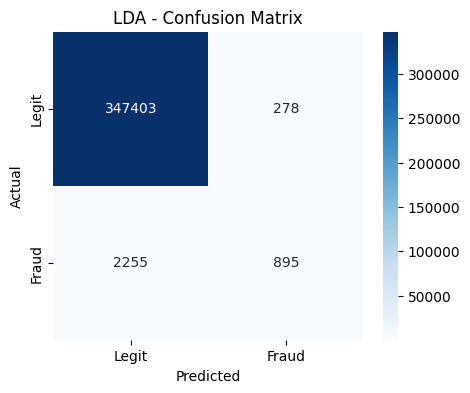

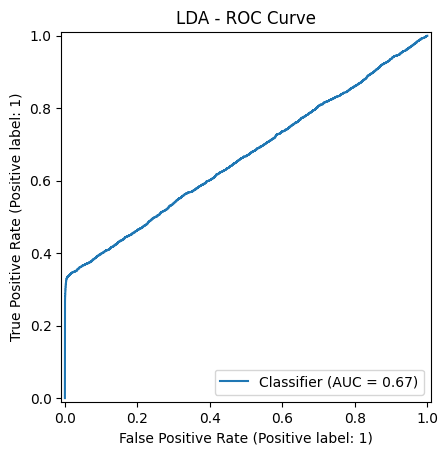

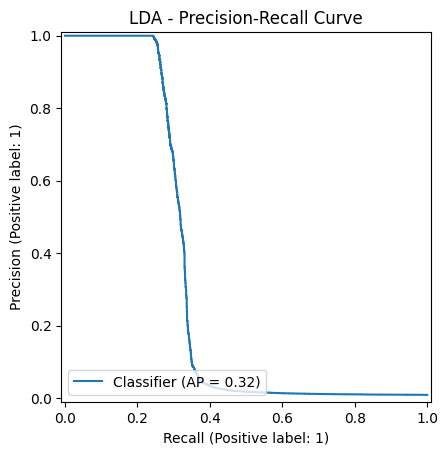

In [ ]:
# evaluate LDA
lda_eval_dict = evaluate.evaluate_w_visualization(y_test=y_test, 
                                                    y_pred=pLDA, 
                                                    y_prob=lda_pipe.predict_proba(X_test)[:,1], 
                                                    model_name=f"LDA")


==================== Logistic Regression ====================
              precision    recall  f1-score   support

       Legit       0.99      1.00      1.00    347681
       Fraud       0.72      0.30      0.43      3150

    accuracy                           0.99    350831
   macro avg       0.86      0.65      0.71    350831
weighted avg       0.99      0.99      0.99    350831

ROC-AUC:  0.6660
PR-AUC:   0.3275


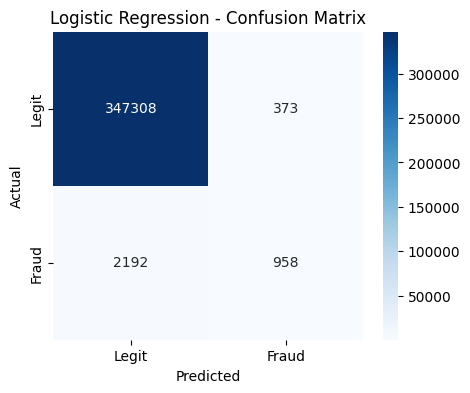

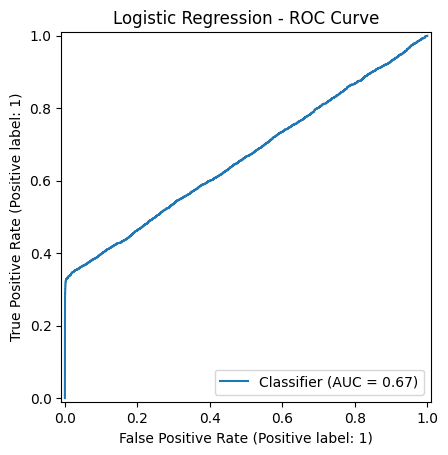

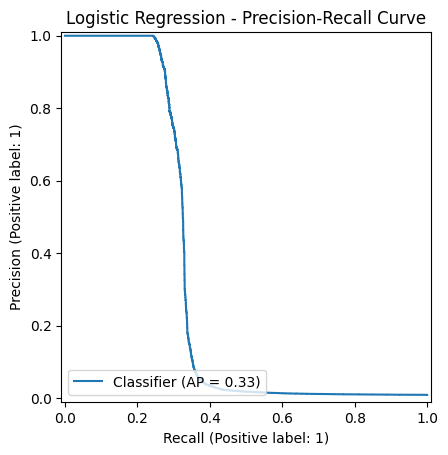

In [ ]:
# evaluate Logistic Regression
lr_eval_dict = evaluate.evaluate_w_visualization(y_test=y_test, 
                                                    y_pred=(pLR >= mvLR).astype(int), 
                                                    y_prob=pLR, 
                                                    model_name=f"Logistic Regression")

In [ ]:
def or_ensemble(pKNN, pLDA, pLR, mvLR):
    """
    Custom OR-based ensemble with LR arbitration.
    
    Parameters
    ----------
    pKNN : array-like, binary predictions from KNN
    pLDA : array-like, binary predictions from LDA
    pLR  : array-like, probability scores from LR
    mvLR : float, mean LR probability threshold (computed on train set)
    
    Returns
    -------
    pOR  : np.ndarray, final ensemble predictions
    """
    pKNN = np.array(pKNN)
    pLDA = np.array(pLDA)
    pLR  = np.array(pLR)
    
    pOR = np.zeros(len(pKNN), dtype=int)  # initialize all to 0

    for i in range(len(pOR)):

        # ── Case 1: At least one model says non-fraud ─────────────────────
        if pKNN[i] == 0 or pLDA[i] == 0:
            if pLR[i] < mvLR:
                pOR[i] = 0
            # else: pOR[i] stays 0 (ambiguous → conservative, default)

        # ── Case 2: At least one model says fraud ─────────────────────────
        elif pKNN[i] == 1 or pLDA[i] == 1:
            if pLR[i] > mvLR:
                pOR[i] = 1
            # else: pOR[i] stays 0 (LR not confident enough → non-fraud)

        # ── Case 3: Fallback (unreachable with binary classifiers) ────────
        else:
            pOR[i] = pKNN[i]

    return pOR

In [ ]:
# train ensemble method
pOR = or_ensemble(pKNN, pLDA, pLR, mvLR)

print(pOR[:5])

[0 0 0 0 0]



==================== OR Ensemble Method ====================
              precision    recall  f1-score   support

       Legit       0.99      1.00      1.00    347681
       Fraud       1.00      0.22      0.36      3150

    accuracy                           0.99    350831
   macro avg       1.00      0.61      0.68    350831
weighted avg       0.99      0.99      0.99    350831

ROC-AUC:  Not available (y_prob=None)
PR-AUC:   Not available (y_prob=None)


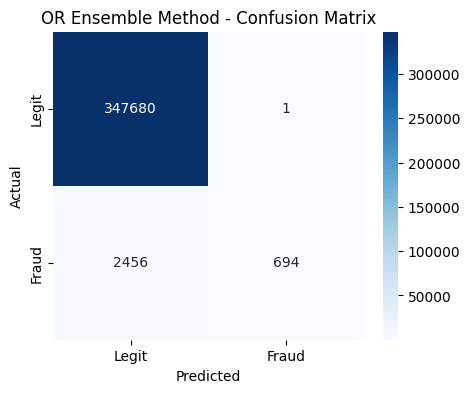

In [ ]:
# evaluate ensemble method
ensemble_eval_dict = evaluate.evaluate_w_visualization(y_test=y_test, 
                                                    y_pred=pOR, 
                                                    model_name=f"OR Ensemble Method")

#### LGBM Baseline Model

In [16]:
from lightgbm import LGBMClassifier

lgbm_pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", LGBMClassifier(
        class_weight="balanced",
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        verbosity=-1
    ))
])

In [17]:
lgbm_pipe.fit(X_train, y_train)

y_lgbm_prob = lgbm_pipe.predict_proba(X_test)[:, 1]

d:\ITI Materials\Projects\Finaira Fraud Detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [18]:
lgbm_best_threshold, lgbm_results_df = evaluate.find_best_threshold(
    y_test,
    y_lgbm_prob,
    metric="f1"
)


Best threshold (by f1): 0.96
Precision: 0.799
Recall:    0.311
F1:        0.448


In [19]:
y_lgbm_pred = (y_lgbm_prob >= lgbm_best_threshold).astype(int)


==================== LightGBM ====================
              precision    recall  f1-score   support

       Legit       0.99      1.00      1.00    347681
       Fraud       0.80      0.31      0.45      3150

    accuracy                           0.99    350831
   macro avg       0.90      0.66      0.72    350831
weighted avg       0.99      0.99      0.99    350831

ROC-AUC:  0.6639
PR-AUC:   0.3195


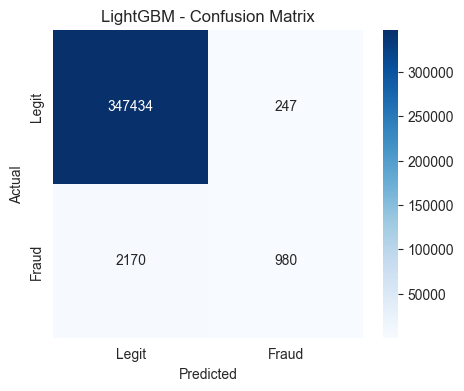

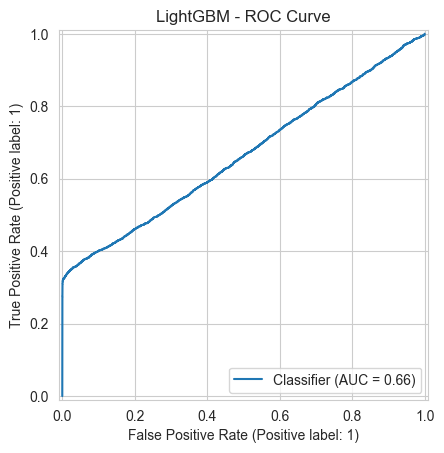

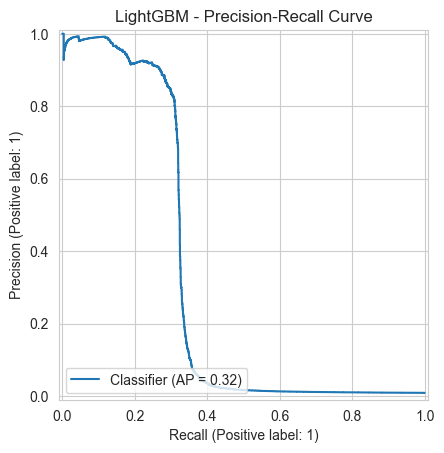

In [20]:
# evaluate LightGBM
lgbm_eval_dict = evaluate.evaluate_w_visualization(y_test=y_test, 
                                                    y_pred=y_lgbm_pred, 
                                                    y_prob=y_lgbm_prob, 
                                                    model_name=f"LightGBM")

#### Models Comparison

In [ ]:
models_eval = [ensemble_eval_dict, knn_eval_dict, lda_eval_dict, lr_eval_dict, lgbm_eval_dict]

In [ ]:
rows = []

for m in models_eval:
    precision, recall, f1, accuracy = evaluate.extract_classification_metrics(
        m["confusion_matrix"]
    )

    rows.append({
        "model": m["model_name"],
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": m["roc_auc"],
        "pr_auc": m["pr_auc"]
    })

comparison_df = pd.DataFrame(rows)

comparison_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,OR Ensemble Method,0.992997,0.998561,0.220317,0.360988,NaN,NaN
1,KNN,0.992999,0.994302,0.221587,0.362409,0.634781,0.259556
2,LDA,0.992780,0.763001,0.284127,0.414064,0.666892,0.322453
3,Logistic Regression,0.992689,0.719760,0.304127,0.427583,0.666019,0.327541
4,LightGBM,0.993111,0.798696,0.311111,0.447795,0.663894,0.319460


LightGBM achieved the highest threshold-dependent performance, obtaining an F1-score of 0.448 and a recall of 0.311, outperforming all other evaluated models. Logistic Regression achieved a slightly higher PR-AUC (0.328 vs. 0.319), indicating marginally better ranking ability. However, given the project's objective of fraud detection, LightGBM was selected as the final baseline model due to its superior balance between precision and recall.